# Trabajo práctico N.º 2: Representación vectorial de texto: Embeddings y búsqueda semántica
**Materia:** Procesamiento del lenguaje natural  
**Integrantes:** Aiup Agustin, Ferreira da Camara Facundo, Paoloni Franco, Silva Julian.

In [1]:
import pandas as pd
import re
import numpy as np
import json
import ast
import matplotlib.pyplot as plt
from gensim.models import KeyedVectors
from gensim.utils import simple_preprocess
from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer
from IPython.display import display

c:\Users\Agus\Desktop\Agustin\UNR\2 - Segundo\4 - Cuarto cuatrimestre\Procesamiento del lenguaje natural\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../data/libros.csv")

print(f"Cantidad de libros: {len(df)}")
df.head()

Cantidad de libros: 120


,id,titulo,autores,generos,serie,sinopsis,url_libro,categoria_origen,fecha_extraccion
0,1,El papá de las bellezas,"[""Felipe Trigo""]","[""Realista"", ""Relato""]",NaN,"El papá de las bellezas , una obra maestra de ...",https://ww3.lectulandia.com/book/el-papa-de-la...,Realismo,2026-09-11
1,2,La última cerilla,"[""Marie Vareille""]","[""Novela"", ""Psicológico"", ""Realista""]",NaN,Las cifras no mienten: tres de cada cuatro niñ...,https://ww3.lectulandia.com/book/la-ultima-cer...,Realismo,2026-09-11
2,3,La enjuta,"[""Víctor Català""]","[""Realista"", ""Relato""]",NaN,En estos relatos la autora presenta una radiog...,https://ww3.lectulandia.com/book/la-enjuta/,Realismo,2026-09-11
3,4,En el camping,"[""Soledad Puértolas""]","[""Realista"", ""Relato""]",NaN,El esplendor de Soledad Puértolas en su madure...,https://ww3.lectulandia.com/book/en-el-camping/,Realismo,2026-09-11
4,5,Koljós,"[""Emmanuel Carrère""]","[""Ensayo"", ""Memorias"", ""Novela"", ""Realista""]",NaN,"Un libro total, una construcción narrativa des...",https://ww3.lectulandia.com/book/koljos/,Realismo,2026-09-11


## Parte A — Preparación del corpus y decisiones de preprocesamiento

Todo preprocesamiento sobre texto natural implica una pérdida deliberada de información en favor de la reducción de la dispersión dimensional:
* **Conversión a minúsculas:** Reduce el vocabulario unificando variantes, pero elimina la distinción de entidades nombradas.
* **Remoción de signos de puntuación:** Facilita la coincidencia de tokens, pero destruye las fronteras oracionales y la entonación discursiva.
* **Eliminación de diacríticos/acentos:** Evita desajustes ortográficos en búsquedas rápidas, a costa de perder distinciones semánticas y gramaticales.
* **Filtrado de stopwords:** Suprime términos de altísima frecuencia para concentrar la atención en términos léxicos portadores de significado, descartando relaciones funcionales y negaciones.

**Decisión metodológica:**  
Este preprocesamiento destructivo es adecuado y necesario para modelos de bolsa de palabras (TF-IDF) y representaciones estáticas (Word2Vec). Sin embargo, resulta contraproducente para modelos de lenguaje contextuales (SBERT), los cuales dependen de la sintaxis, el orden, las mayúsculas y la puntuación original. Por lo tanto, el preprocesamiento pertenece al modelo y no al corpus: mantenemos el texto crudo para SBERT y el texto normalizado ("puro") para los modelos léxicos y de palabras promediadas.

In [3]:
def convertir_a_string(valor):
    if pd.isna(valor):
        return ""
    
    if isinstance(valor, str):
        try:
            valor_parseado = ast.literal_eval(valor)
            
            if isinstance(valor_parseado, list):
                return " ".join(str(x) for x in valor_parseado)
            
            return str(valor_parseado)
        
        except (ValueError, SyntaxError):
            return valor
    
    if isinstance(valor, list):
        return " ".join(str(x) for x in valor)
    
    return str(valor)


In [4]:
columnas = [
    "titulo",
    "autores",
    "generos",
    "serie",
    "sinopsis"
]

for columna in columnas:
    df[columna] = df[columna].apply(convertir_a_string)


In [5]:
df["puro"] = df[columnas].agg(" ".join, axis=1)

df["puro"] = (
    df["puro"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [6]:
df[["titulo", "autores", "generos", "serie", "sinopsis", "puro"]].head()

,titulo,autores,generos,serie,sinopsis,puro
0,El papá de las bellezas,Felipe Trigo,Realista Relato,,"El papá de las bellezas , una obra maestra de ...",El papá de las bellezas Felipe Trigo Realista ...
1,La última cerilla,Marie Vareille,Novela Psicológico Realista,,Las cifras no mienten: tres de cada cuatro niñ...,La última cerilla Marie Vareille Novela Psicol...
2,La enjuta,Víctor Català,Realista Relato,,En estos relatos la autora presenta una radiog...,La enjuta Víctor Català Realista Relato En est...
3,En el camping,Soledad Puértolas,Realista Relato,,El esplendor de Soledad Puértolas en su madure...,En el camping Soledad Puértolas Realista Relat...
4,Koljós,Emmanuel Carrère,Ensayo Memorias Novela Realista,,"Un libro total, una construcción narrativa des...",Koljós Emmanuel Carrère Ensayo Memorias Novela...


In [7]:
STOPWORDS_ES = {
    "a", "al", "algo", "algunas", "algunos", "ante", "antes", "como",
    "con", "contra", "cual", "cuando", "de", "del", "desde", "donde",
    "dos", "el", "ella", "ellas", "ellos", "en", "entre", "era", "es",
    "esa", "esas", "ese", "eso", "esos", "esta", "estas", "este", "esto",
    "estos", "fue", "ha", "han", "hasta", "hay", "la", "las", "le", "les",
    "lo", "los", "más", "me", "mi", "mis", "muy", "no", "nos", "o", "para",
    "pero", "por", "que", "qué", "se", "sea", "ser", "si", "sí", "sin",
    "sobre", "son", "su", "sus", "también", "te", "tiene", "tienen", "todo",
    "todos", "tu", "tus", "un", "una", "uno", "unos", "y", "ya"
}

def remover_acentos(texto):
    texto = re.sub(r"[áàäâãå]", "a", texto)
    texto = re.sub(r"[éèëê]", "e", texto)
    texto = re.sub(r"[íìïî]", "i", texto)
    texto = re.sub(r"[óòöôõ]", "o", texto)
    texto = re.sub(r"[úùüû]", "u", texto)
    texto = texto.replace("ñ", "n")
    
    return texto

In [8]:


def limpiar_texto(texto):
    # 1. Lowercase
    texto = texto.lower()

    # 2. Eliminar signos de puntuación
    texto = re.sub(r"[^\w\s]", "", texto)

    # 3. Normalizar espacios
    texto = re.sub(r"\s+", " ", texto).strip()

    # 4. Remover acentos
    texto = remover_acentos(texto)
    
    # 5. Remover stopwords
    palabras = texto.split()
    palabras = [
        palabra for palabra in palabras
        if palabra not in STOPWORDS_ES
    ]

    return " ".join(palabras)


# Modificamos directamente la columna "puro"
df["puro"] = df["puro"].apply(limpiar_texto)

In [9]:
df["puro"].head()

0    papa bellezas felipe trigo realista relato pap...
1    ultima cerilla marie vareille novela psicologi...
2    enjuta victor catala realista relato relatos a...
3    camping soledad puertolas realista relato espl...
4    koljos emmanuel carrere ensayo memorias novela...
Name: puro, dtype: str

In [10]:
# Copiamos el df base para usarlo en todos los items sin riesgos de sobreescribirlo
df_tfidf = df.copy()
df_word2vec = df.copy()

### A — Vectorización léxica dispersa (TF-IDF)

Construimos la matriz de documentos mediante TF-IDF sobre el texto normalizado. Cada libro queda representado en un espacio de altísima dimensión (el tamaño exacto del vocabulario resultante), donde cada componente refleja la frecuencia de un término ponderada por su especificidad en el corpus (IDF). Esta matriz servirá como nuestra línea de base léxica.

In [11]:
# Crear el vectorizador
vectorizador = TfidfVectorizer()

# Calcular TF-IDF
matriz_tfidf = vectorizador.fit_transform(df_tfidf["puro"])

# Guardar el vector de cada libro en df["vec"]
df_tfidf["vec"] = list(matriz_tfidf.toarray())

In [12]:
vector = df_tfidf["vec"].iloc[0]
terminos = vectorizador.get_feature_names_out()

for termino, valor in zip(terminos, vector):
    if valor > 0:
        print(f"{termino}: {valor:.4f}")

ambiente: 0.1235
audaz: 0.1342
belleza: 0.1101
bellezas: 0.2684
bello: 0.1342
cambio: 0.1012
complejidad: 0.1235
contexto: 0.1160
cotidiana: 0.1160
crea: 0.1342
critica: 0.0830
cuidadoso: 0.1342
deseos: 0.1101
despliega: 0.1160
enfoque: 0.1342
entrelaza: 0.1342
entrelazado: 0.1342
espana: 0.0977
estetica: 0.1342
estilo: 0.0946
evocador: 0.1235
evolucion: 0.1235
examinan: 0.1342
felipe: 0.2025
femenina: 0.1053
grotesco: 0.1342
hacia: 0.0894
humanas: 0.0946
humanos: 0.1101
inicios: 0.1342
invita: 0.1053
lector: 0.0764
libro: 0.0657
maestra: 0.1012
motivaciones: 0.1342
narrativo: 0.1053
obra: 0.0678
papa: 0.2684
papel: 0.1101
personajes: 0.0736
presentando: 0.1342
profundamente: 0.1012
propias: 0.1160
publicado: 0.1101
realidad: 0.0795
realista: 0.0263
refleja: 0.1101
reflexion: 0.1160
relaciones: 0.0946
relato: 0.0597
sensualidad: 0.1160
siglo: 0.0919
social: 0.1837
sociedad: 0.0830
sumerge: 0.1160
tensiones: 0.1160
transformaciones: 0.1342
trigo: 0.3159
vibrante: 0.1235
vida: 0.0430
xx:

In [13]:
vector = df_tfidf["vec"].iloc[0]
terminos = vectorizador.get_feature_names_out()

top_10 = sorted(
    zip(terminos, vector),
    key=lambda x: x[1],
    reverse=True
)[:10]

for termino, valor in top_10:
    print(f"{termino}: {valor:.4f}")

trigo: 0.3159
bellezas: 0.2684
papa: 0.2684
felipe: 0.2025
social: 0.1837
audaz: 0.1342
bello: 0.1342
crea: 0.1342
cuidadoso: 0.1342
enfoque: 0.1342


In [14]:
# Guardar los vectores en un archivo físico
np.savez_compressed(
    "vectores_libros.npz",
    ids=df_tfidf["id"].to_numpy(),
    vectores=np.stack(df_tfidf["vec"].to_numpy())
)

In [15]:
datos = np.load("vectores_libros.npz")

ids = datos["ids"]
vectores = datos["vectores"]

vector = vectores[0]
terminos = vectorizador.get_feature_names_out()

top_10 = sorted(
    zip(terminos, vector),
    key=lambda x: x[1],
    reverse=True
)[:10]

for termino, valor in top_10:
    print(f"{termino}: {valor:.4f}")

trigo: 0.3159
bellezas: 0.2684
papa: 0.2684
felipe: 0.2025
social: 0.1837
audaz: 0.1342
bello: 0.1342
crea: 0.1342
cuidadoso: 0.1342
enfoque: 0.1342


## Parte B — Word2Vec: Entrenamiento propio vs. Modelo preentrenado

In [16]:
df_word2vec["puro"].head()[0]

'papa bellezas felipe trigo realista relato papa bellezas obra maestra felipe trigo despliega enfoque audaz hacia relaciones humanas complejidad belleza femenina libro publicado contexto cambio social inicios siglo xx espana refleja tensiones transformaciones sociedad evolucion estilo narrativo cuidadoso evocador trigo sumerge lector realidad sensualidad entrelaza critica social presentando personajes profundamente humanos examinan propias motivaciones deseos entrelazado bello grotesco crea ambiente vibrante invita reflexion papel estetica vida cotidiana'

### Modelo prearmado

In [17]:
# Cargamos el modelo preentrenado
modelo = KeyedVectors.load_word2vec_format(
    "../data/SBW-vectors-300-min5.bin.gz",
    binary=True
)

In [18]:

# Función para vectorizar cada libro
def vectorizar_texto(texto):
    if not isinstance(texto, str) or not texto.strip():
        return np.zeros(300, dtype=np.float32)

    palabras = texto.split()

    # Conservar únicamente las palabras conocidas por el modelo
    vectores = [
        modelo[palabra]
        for palabra in palabras
        if palabra in modelo
    ]

    # Si ninguna palabra existe en el vocabulario
    if not vectores:
        return np.zeros(300, dtype=np.float32)

    # Promediar los vectores de las palabras
    return np.mean(vectores, axis=0)

In [19]:
# Crear un DataFrame nuevo con las columnas id y vec_sbw
df_sbw = df_word2vec[["id", "puro"]].copy()

df_sbw["vec_sbw"] = df_sbw["puro"].apply(vectorizar_texto)

# Conservar únicamente las columnas necesarias
df_sbw = df_sbw[["id", "vec_sbw"]]

# Verificar dimensiones del vector
print(df_sbw["vec_sbw"].iloc[0].shape)  # (300,)

# Mostrar las primeras filas
df_sbw.head()

(300,)


,id,vec_sbw
0,1,"[0.035693604, -0.10230952, 0.006473552, -0.094..."
1,2,"[-0.019949144, -0.070138745, 0.05399907, -0.08..."
2,3,"[0.03255266, -0.10716788, 0.059871107, -0.1144..."
3,4,"[0.0110251615, -0.07502993, 0.0578787, -0.0742..."
4,5,"[0.015093292, -0.06422863, 0.01627165, -0.1089..."


### Entrenamiento de Word2Vec de cero sobre corpus reducido
Entrenamos un modelo Word2Vec propio utilizando la arquitectura Skip-Gram (sg=1), ya que estadísticamente suele comportarse mejor que CBOW con corpus pequeños y palabras poco frecuentes.

**Hiperparámetros seleccionados y su justificación:**
* vector_size = 100 (y prueba con 150): En corpus masivos se usan 300 dimensiones. Para un corpus de apenas 120 sinopsis, fijar dimensiones muy altas provocaría una dispersión excesiva y sobreajuste severo.
* window = 5: Captura un contexto semántico moderado alrededor de cada término central.
* min_count = 2: Filtra hapax legomena (palabras que aparecen una sola vez y no aportan señal de coocurrencia), preservando términos característicos aunque tengan baja frecuencia.
* epochs = 10 (y prueba con 20): Permite múltiples pasadas sobre las pocas oraciones disponibles para estabilizar los pesos.
* workers = 1, seed = 42: Asegura la estricta reproducibilidad de los embeddings generados.

In [20]:
textos = df_word2vec["puro"].astype(str)

# Separar en oraciones y tokenizar
oraciones = []

for texto in textos:
    frases = re.split(r'[.!?¿¡\n]+', texto)

    for frase in frases:
        palabras = simple_preprocess(
            frase,
            deacc=True,  # Quita acentos
            min_len=2
        )

        if palabras:
            oraciones.append(palabras)

Cambiamos workers a 1 y seed a 42 por reproducibilidad

In [21]:

# PRUEBA de 100 5 2 10
modelo_propio = Word2Vec(
    sentences=oraciones,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,
    workers=4,
    seed=42,
    epochs=10
)

print("Cantidad de oraciones:", len(oraciones))
print("Tamaño del vocabulario:", len(modelo_propio.wv))

Cantidad de oraciones: 120
Tamaño del vocabulario: 1773


In [22]:
# Testing
palabras = ["perro", "gato", "casa", "computadora"]

for palabra in palabras:
    print(palabra, palabra in modelo_propio.wv)
    
try:
    similares = modelo_propio.wv.most_similar("casa")
    print(similares)

except KeyError:
    print('La palabra no está en el vocabulario del modelo.')

perro True
gato False
casa True
computadora False
[('mantiene', 0.9982847571372986), ('va', 0.9982599020004272), ('espana', 0.9982389211654663), ('estado', 0.9981681108474731), ('lago', 0.998153030872345), ('carrera', 0.9981521368026733), ('secretos', 0.9981490969657898), ('descubre', 0.9981489181518555), ('hija', 0.9981439709663391), ('protagonista', 0.9981399178504944)]


In [23]:
# PRUEBA con 150 5 5 20
modelo_propio = Word2Vec(
    sentences=oraciones,
    vector_size=150,
    window=3,
    min_count=3,
    sg=1,
    workers=1,
    seed=42,
    epochs=20
)

print("Cantidad de oraciones:", len(oraciones))
print("Tamaño del vocabulario:", len(modelo_propio.wv))

Cantidad de oraciones: 120
Tamaño del vocabulario: 876


In [24]:
# Testing
palabras = ["perro", "gato", "casa", "computadora"]

for palabra in palabras:
    print(palabra, palabra in modelo_propio.wv)
    
try:
    similares = modelo_propio.wv.most_similar("casa")
    print(similares)

except KeyError:
    print('La palabra no está en el vocabulario del modelo.')

perro True
gato False
casa True
computadora False
[('cualquiera', 0.997378408908844), ('tia', 0.9973612427711487), ('verano', 0.997357964515686), ('profesor', 0.9973362684249878), ('une', 0.9973345994949341), ('julio', 0.9973114132881165), ('fachada', 0.9973111152648926), ('generacion', 0.9972965717315674), ('chile', 0.9972702860832214), ('fortuna', 0.997265636920929)]


### Comparamos modelo preentrenado con modelo propio

In [25]:
# Seleccionamos 4 palabras presentes en ambos vocabularios
palabras_test = ["casa", "vida", "muerte", "tiempo"]
# Filtramos para asegurarnos de que estén en el modelo propio
palabras_validas = [p for p in palabras_test if p in modelo_propio.wv and p in modelo]

print("Palabras evaluadas:", palabras_validas)

# Generamos la tabla comparativa
filas_comparacion = []
for p in palabras_validas:
    vecinos_propio = modelo_propio.wv.most_similar(p, topn=5)
    vecinos_sbw = modelo.most_similar(p, topn=5)
    
    for i in range(5):
        w_propio, s_propio = vecinos_propio[i]
        w_sbw, s_sbw = vecinos_sbw[i]
        filas_comparacion.append({
            "Palabra": p if i == 0 else "",
            "Rango": f"#{i+1}",
            "Modelo Propio (120 docs)": f"{w_propio} ({s_propio:.3f})",
            "Preentrenado SBW": f"{w_sbw} ({s_sbw:.3f})"
        })

df_vecinos_comp = pd.DataFrame(filas_comparacion)
display(df_vecinos_comp)

Palabras evaluadas: ['casa', 'vida', 'muerte', 'tiempo']


,Palabra,Rango,Modelo Propio (120 docs),Preentrenado SBW
0,casa,#1,cualquiera (0.997),habitación (0.691)
1,,#2,tia (0.997),mansión (0.669)
2,,#3,verano (0.997),avisarla (0.642)
3,,#4,profesor (0.997),apartamento (0.636)
4,,#5,une (0.997),Kirrín (0.636)
5,vida,#1,dramatica (0.997),vidas (0.656)
6,,#2,figura (0.997),vivir (0.575)
7,,#3,lado (0.997),Encarnar (0.565)
8,,#4,recuerda (0.997),viday (0.563)
9,,#5,verdadero (0.997),reinsertarlo (0.557)


### Justificación teórica: Promedio de vectores de palabras

Al construir el vector de documento promediando los vectores de sus palabras constitutivas:
1. **Pérdida de orden y sintaxis**: Se descarta la estructura gramatical y el orden de los términos.
2. **Pérdida de peso temático (dilución semántica)**: Todas las palabras aportan con ponderación uniforme ($1/N$). Términos genéricos o secundarios tienen el mismo impacto geométrico que las palabras clave distintivas del argumento.
3. **Pérdida de relaciones de negación y polisemia**: La negación se anula y las palabras con múltiples acepciones quedan promediadas en un punto intermedio engañoso.
4. **Por qué se utiliza a pesar de sus limitaciones**: Es un baseline denso eficiente, de cómputo lineal $O(N)$ y de dimensión fija (300), que permite operar con similitud coseno sin requerir arquitecturas complejas de agregación.

## Parte C — Modelo de Oración: Sentence-BERT (SBERT)

Para superar la pérdida de contexto y la insensibilidad al orden gramatical inherente al promedio de palabras, implementamos un modelo de oraciones preentrenado mediante arquitectura Transformer: distiluse-base-multilingual-cased-v1.

A diferencia de los modelos anteriores:
1. **Entrada de texto:** Procesa las sinopsis crudas (preservando mayúsculas, acentuación y puntuación), dado que el mecanismo de autoatención (self-attention) aprovecha explícitamente estas señales sintácticas.
2. **Tokens y truncamiento:** Verificamos la propiedad intrínseca de longitud máxima (max_seq_length = 128 tokens sub-palabra). Se contabiliza el volumen de documentos del corpus que superan esta longitud y sufren truncamiento pasivo.

In [26]:
# Cargar el corpus
df_sbert = pd.read_csv("../data/libros.csv")
sinopsis_crudas = df_sbert['sinopsis'].tolist()

# Cargar el modelo pre-entrenado
model_name = 'distiluse-base-multilingual-cased-v1'
model = SentenceTransformer(model_name)

# Reporte de propiedades del modelo
dim = model.get_embedding_dimension()
max_seq_len = model.max_seq_length

print(f"Dimensión del embedding: {dim}")
print(f"Límite de tokens del modelo (max_seq_length): {max_seq_len}")

# 4. Cálculo de documentos truncados
tokenizer = model.tokenizer
token_counts = [len(tokenizer.encode(texto, truncation=False)) for texto in sinopsis_crudas]

truncados = sum(1 for c in token_counts if c > max_seq_len)
pct_truncados = (truncados / len(sinopsis_crudas)) * 100

print(f"Documentos que superan el límite y se truncan: {truncados} de {len(sinopsis_crudas)} ({pct_truncados:.1f}%)")

# Generar embeddings y mantenerlos en memoria
embeddings_sbert = model.encode(sinopsis_crudas, show_progress_bar=True, normalize_embeddings=True)

# Guardado en memoria: disponible como array NumPy y como columna del DataFrame
df_sbert['embedding_sbert'] = list(embeddings_sbert)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1135.55it/s]
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (166 > 128). Running this sequence through the model will result in indexing errors


Dimensión del embedding: 512
Límite de tokens del modelo (max_seq_length): 128
Documentos que superan el límite y se truncan: 101 de 120 (84.2%)


Batches: 100%|██████████| 4/4 [00:04<00:00,  1.21s/it]


## Parte D — Comparación y visualización de los espacios

Comparamos los tres espacios construidos en las partes A–C sobre el mismo corpus de 120 libros y las mismas consultas:

| Espacio | Variable | Dimensión |
| --- | --- | --- |
| TF-IDF | df_tfidf["vec"] | tamaño del vocabulario |
| Word2Vec promedio (SBW) | df_sbw["vec_sbw"] | 300 |
| SBERT (distiluse) | embeddings_sbert | 512 |

Las tres representaciones están alineadas fila a fila (todas derivan del mismo data/libros.csv leído en el mismo orden), así que la fila "i" es el mismo libro en los tres espacios.

In [27]:

# Identificadores y títulos en el orden de las filas (común a los tres espacios)
doc_ids = df["id"].to_numpy()
titulos = df["titulo"].to_numpy()

# Matriz densa (120 x d) por espacio
X_tfidf = np.vstack(df_tfidf["vec"].to_numpy())          # (120, |vocab|)
X_sbw   = np.vstack(df_sbw["vec_sbw"].to_numpy())        # (120, 300)
X_sbert = np.vstack(df_sbert["embedding_sbert"].to_numpy())  # (120, 512)

print("TF-IDF :", X_tfidf.shape)
print("SBW    :", X_sbw.shape)
print("SBERT  :", X_sbert.shape)

# Embebido de la CONSULTA en cada espacio, replicando el mismo preproceso que
# se usó para los documentos, para que la comparación sea justa.
def q_tfidf(texto):
    # mismos pasos de limpieza que df_tfidf["puro"]
    return vectorizador.transform([limpiar_texto(texto)]).toarray()

# Limpiamos el texto de las busquedas para evitar errores de acentos, signos, etc.
def q_sbw(texto):
  return vectorizar_texto(limpiar_texto(texto)).reshape(1, -1)

def q_sbert(texto):
    return model.encode([texto], normalize_embeddings=True)

# nombre -> (matriz de documentos, función que embebe la consulta)
espacios = {
    "TF-IDF":          (X_tfidf, q_tfidf),
    "Word2Vec (SBW)":  (X_sbw,   q_sbw),
    "SBERT":           (X_sbert, q_sbert),
}

TF-IDF : (120, 5160)
SBW    : (120, 300)
SBERT  : (120, 512)


### D.1 — Ranking lado a lado

Para cada consulta embebemos el texto en cada espacio y ordenamos los 120 libros por similitud coseno. Mostramos el top-5 de los tres modelos en paralelo; "✓" marca los documentos que el gold standard de queries.json considera relevantes y "·" los que no.

In [28]:
# Cargar el conjunto de evaluación (juicios de relevancia hechos a mano)
with open("queries.json", encoding="utf-8") as f:
    QUERIES = {c["id"]: c for c in json.load(f)["consultas"]}

def gold_ids(qid):
    return {r["id"] for r in QUERIES[qid]["relevantes"]}

def rankear(texto, X, qfn, k=5):
    q = qfn(texto)
    sims = cosine_similarity(q, X)[0]
    idx = np.argsort(sims)[::-1][:k]
    return idx, sims[idx]

def tabla_ranking(qid, k=5):
    c = QUERIES[qid]
    texto, gold = c["texto"], gold_ids(qid)
    columnas = {}
    for nombre, (X, qfn) in espacios.items():
        idx, sims = rankear(texto, X, qfn, k)
        columnas[nombre] = [
            f"{'✓' if doc_ids[i] in gold else '·'} {titulos[i]} ({s:.2f})"
            for i, s in zip(idx, sims)
        ]
    tab = pd.DataFrame(columnas, index=[f"#{r}" for r in range(1, k + 1)])
    print(f"\n[{qid}] {texto}")
    print("Relevantes (gold):", ", ".join(str(g) for g in sorted(gold)))
    return tab

# Al menos 3 consultas en lenguaje natural (editable).
# Incluimos q11 como control: misma novela en dos traducciones descrita SIN
# solapamiento léxico, donde TF-IDF no puede recuperarla por construcción.
consultas_demo = ["q01", "q02", "q04", "q11"]

for qid in consultas_demo:
    display(tabla_ranking(qid, k=5))


[q01] novelas sobre la guerra y cómo marca la vida de quienes la atraviesan
Relevantes (gold): 8, 10, 49, 54, 64, 85, 103


,TF-IDF,Word2Vec (SBW),SBERT
#1,· La fiesta (0.11),· La vida de ellas (0.82),· Sí sé por qué (0.36)
#2,· El desván de las musas dormidas (0.10),· Once maneras de sentirse solo (0.82),· Reloj sin manecillas (0.35)
#3,· Fondo buitre (0.08),✓ Huríes (0.82),· Una hora mala la tiene cualquiera… (0.35)
#4,· Caracas muerde (0.07),· Natasha (0.81),✓ Las cenizas de Bagdad (0.35)
#5,· Adversarios admirables (0.07),· Reloj sin manecillas (0.81),✓ Huríes (0.35)



[q02] historias ambientadas en Japón
Relevantes (gold): 48, 52, 71, 77


,TF-IDF,Word2Vec (SBW),SBERT
#1,· Historias de médicos (0.09),· Arne (0.71),✓ Los amantes de la noche (0.43)
#2,✓ El pabellón de oro (trad. Carlos Rubio) (0.09),· Treinta hombres y sus sombras (0.70),✓ Una joven en Tokio (0.31)
#3,· Lecturas mínimas (0.07),· Fantasmas y retratos de la tradición (0.69),✓ El pabellón de oro (trad. Carlos Rubio) (0.29)
#4,· La enjuta (0.06),· Primer amor y otros pesares (0.68),· Once maneras de sentirse solo (0.28)
#5,· Reveladoras (0.05),· Cuentos completos (0.68),· La enjuta (0.24)



[q04] un asesinato y la investigación que viene después
Relevantes (gold): 27, 31, 61, 69, 72, 74, 93


,TF-IDF,Word2Vec (SBW),SBERT
#1,· Morir en la arena (0.08),✓ La bala (0.78),✓ Botánico (0.33)
#2,· De mujeres con hombres (0.06),✓ Botánico (0.76),✓ La vida privada de Piero Garza (0.30)
#3,· Cumpleaños; Los bancos del Prado; Los vended...,✓ El club de lectura (0.74),· De mujeres con hombres (0.22)
#4,· ¿Acaso no matan a los caballos? / Luces de H...,· Adiós al séptimo de línea V: El regreso de l...,✓ El club de lectura (0.22)
#5,· Comida familiar (0.05),· Morir en la arena (0.72),✓ Las víctimas (0.22)



[q11] historia sentimental entre un agricultor sin esposa y una chica pobre que cuida ovejas
Relevantes (gold): 44, 57


,TF-IDF,Word2Vec (SBW),SBERT
#1,· Fantasmas y retratos de la tradición (0.08),✓ La charca del diablo (0.85),· Madonna no nació en Wisconsin (0.41)
#2,· La bala (0.06),· Una joven en Tokio (0.83),· Huríes (0.37)
#3,· Criaturita (0.06),✓ El Pantano del Diablo (0.83),"· El café frío, la cerveza caliente (0.32)"
#4,· No pienses en un elefante rosa (0.05),· Perfectamente imperfecta (0.82),✓ El Pantano del Diablo (0.32)
#5,· De mujeres con hombres (0.05),· La vida privada de Piero Garza (0.81),· Animales domésticos (0.31)


**Lectura del ranking (resultados de esta corrida):**

- **TF-IDF casi no sirve para estas consultas en lenguaje natural.** En q01 (guerra) y q04 (crimen) mete 0 relevantes en el top-5, y las similitudes son minúsculas (~0.05–0.11): como la consulta no comparte las palabras exactas de las sinopsis, no tiene con qué puntuar. Solo acierta cuando hay coincidencia léxica literal (q02: "El pabellón de oro", 1/5).
- **Word2Vec (SBW) recupera algo pero con similitudes planas.** Todos los candidatos salen con ~0.90–0.94, o sea apenas se distinguen entre sí (ver D.2). Aun así acierta temas con vocabulario concreto: q04 (crimen) acierta 4/5. En temas más difusos (q01 guerra) acierta 0/5.
- **SBERT es el mejor en intención semántica.** q02 (Japón) 3/5 en los primeros tres puestos, q04 (crimen) 4/5, q01 (guerra) 2/5 (recupera "Las cenizas de Bagdad" y "Huríes" pese a no repetir la palabra "guerra").
- **Control q11 (misma novela, dos traducciones, sin solapamiento léxico):** TF-IDF 0/2 (imposible por construcción); SBW y SBERT recuperan 1 de las 2 en el top-5. Confirma que los modelos semánticos capturan el argumento aunque el vocabulario no coincida.

### D.2 — Distribución de similitudes entre pares

Tomamos todos los pares distintos de documentos (C(120,2) = 7140) y miramos la distribución de su similitud coseno en cada espacio. La idea: un espacio donde todo se parece a todo no discrimina, aunque el ranking devuelva algo. Una media alta con desvío chico es señal de poca capacidad de separación.

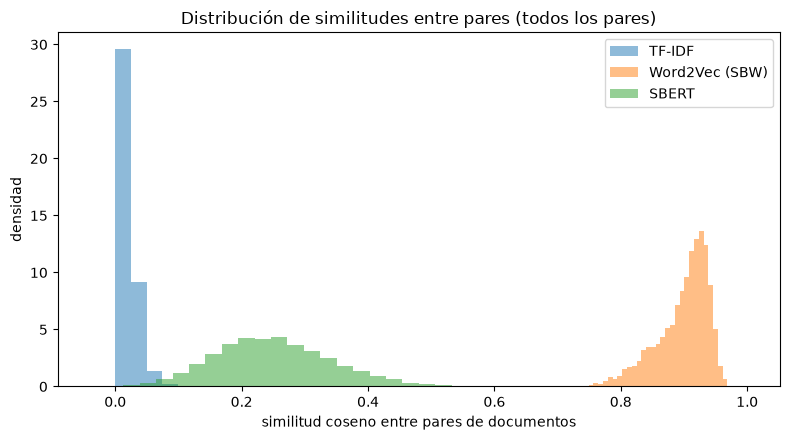

,media,desvio,min,max,rango
modelo,,,,,
TF-IDF,0.019,0.022,0.000,0.990,0.989
Word2Vec (SBW),0.898,0.041,0.696,0.999,0.303
SBERT,0.252,0.094,-0.039,1.000,1.039


In [29]:
def sims_pares(X):
    S = cosine_similarity(X)
    iu = np.triu_indices(X.shape[0], k=1)   # pares i<j, sin la diagonal
    return S[iu]

resumen = []
plt.figure(figsize=(8, 4.5))
for nombre, (X, _) in espacios.items():
    v = sims_pares(X)
    resumen.append({
        "modelo": nombre,
        "media":  v.mean(),
        "desvio": v.std(),
        "min":    v.min(),
        "max":    v.max(),
        "rango":  v.max() - v.min(),
    })
    plt.hist(v, bins=40, alpha=0.5, density=True, label=nombre)

plt.xlabel("similitud coseno entre pares de documentos")
plt.ylabel("densidad")
plt.title("Distribución de similitudes entre pares (todos los pares)")
plt.legend()
plt.tight_layout()
plt.show()

pd.DataFrame(resumen).set_index("modelo").round(3)

**Lectura de la distribución (resultados de esta corrida):**

| modelo | media | desvío | rango |
| --- | --- | --- | --- |
| TF-IDF | 0.019 | 0.021 | 0.989 |
| Word2Vec (SBW) | 0.958 | 0.023 | 0.146 |
| SBERT | 0.252 | 0.094 | 1.039 |

- **TF-IDF (media ≈ 0.02):** Por dispersión, dos documentos cualesquiera son casi ortogonales. Discrimina por ausencia de solapamiento, pero eso mismo lo vuelve inútil cuando la consulta no usa las palabras exactas del documento (ver q11).
- **Word2Vec SBW (media ≈ 0.96, desvío ≈ 0.02):** Todo se parece a todo. Promediar 300 dimensiones sobre textos largos colapsa los vectores hacia una dirección común; el ranking opera sobre diferencias de centésimas y es frágil. Es el caso de libro que la consigna advierte: aunque devuelva un orden, casi no separa.
- **SBERT (media ≈ 0.25, desvío ≈ 0.09):** Media moderada y el mayor desvío de los tres → es el que más margen tiene para distinguir un par relevante de uno irrelevante. Coincide con que sea el mejor en los rankings de D.1.

### D.3 — Proyección 2D por género

Proyectamos los 120 documentos a 2D y los coloreamos por género, una etiqueta que ningún modelo vio durante el entrenamiento/ajuste. Como todo el corpus es "Realista", usamos como color el primer género secundario de cada libro (Novela, Relato, Drama, …), agrupando los menos frecuentes en "Otros".

Usamos PCA (informando la varianza explicada por las 2 componentes) para los tres espacios, y agregamos un t-SNE del espacio SBERT. Las dos lecturas tienen advertencias distintas, comentadas abajo.

In [30]:
# Etiqueta de género principal (el primer género que no sea "Realista")
def genero_principal(g):
    try:
        lst = ast.literal_eval(g) if isinstance(g, str) and g.strip().startswith("[") else str(g).split()
    except (ValueError, SyntaxError):
        lst = str(g).split()
    lst = [x for x in lst if x.lower() != "realista"]
    return lst[0] if lst else "Realista"

generos_doc = df_sbert["generos"].apply(genero_principal).to_numpy()

# Agrupar los géneros poco frecuentes para que la leyenda sea legible
top_generos = {g for g, _ in Counter(generos_doc).most_common(6)}
generos_plot = np.array([g if g in top_generos else "Otros" for g in generos_doc])

clases = sorted(set(generos_plot))
cmap = plt.get_cmap("tab10", len(clases))
color_de = {c: cmap(i) for i, c in enumerate(clases)}

print("Distribución de géneros usada para el color:")
print(pd.Series(generos_plot).value_counts())

Distribución de géneros usada para el color:
Novela       74
Drama        17
Relato       15
Otros        10
Histórico     3
Ensayo        1
Name: count, dtype: int64


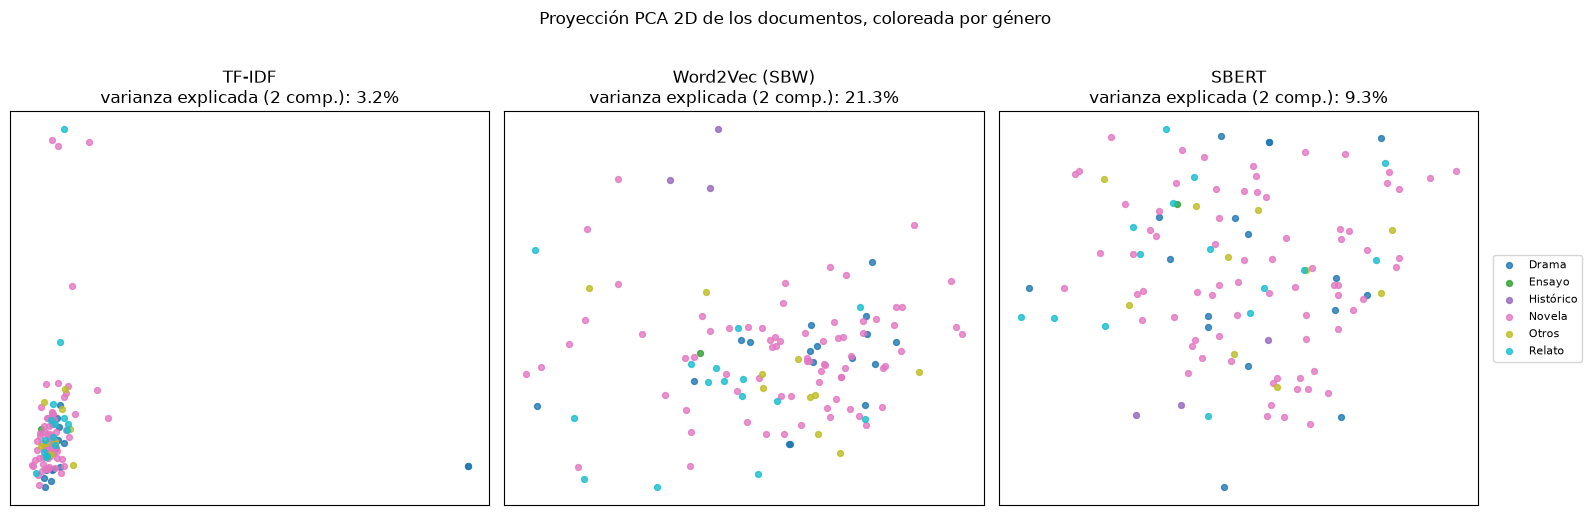

In [31]:
# PCA 2D de cada espacio, coloreado por género
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nombre, (X, _)) in zip(axes, espacios.items()):
    pca = PCA(n_components=2, random_state=42)
    Z = pca.fit_transform(X)
    var = pca.explained_variance_ratio_[:2].sum() * 100
    for c in clases:
        m = generos_plot == c
        ax.scatter(Z[m, 0], Z[m, 1], s=18, alpha=0.8, color=color_de[c], label=c)
    ax.set_title(f"{nombre}\nvarianza explicada (2 comp.): {var:.1f}%")
    ax.set_xticks([]); ax.set_yticks([])

axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.suptitle("Proyección PCA 2D de los documentos, coloreada por género", y=1.02)
plt.tight_layout()
plt.show()

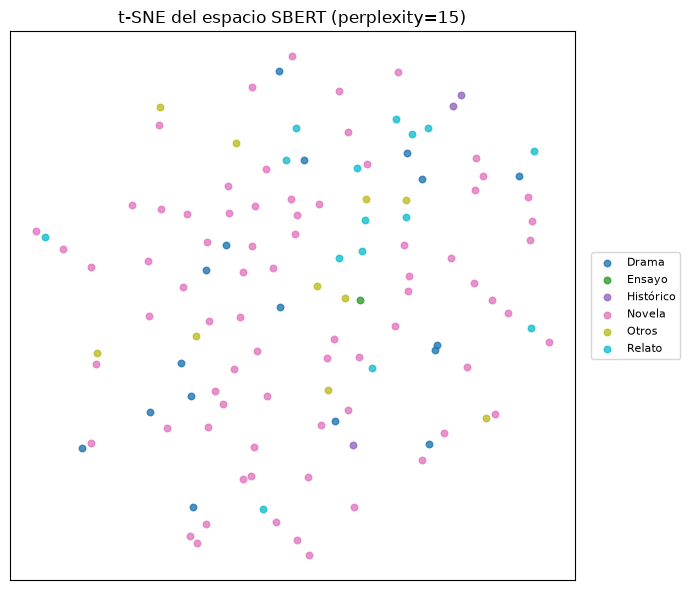

In [32]:
# t-SNE del espacio SBERT
perplexity = 15

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    random_state=42,
)
Zt = tsne.fit_transform(X_sbert)

plt.figure(figsize=(7, 6))
for c in clases:
    m = generos_plot == c
    plt.scatter(Zt[m, 0], Zt[m, 1], s=22, alpha=0.8, color=color_de[c], label=c)
plt.title(f"t-SNE del espacio SBERT (perplexity={perplexity})")
plt.xticks([]); plt.yticks([])
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

## Parte 5 — Evaluación de los modelos: precision@k

Un buscador que "devuelve resultados plausibles" no alcanza: argsort ordena ruido con la misma prolijidad con que ordena señal. Para medir de verdad usamos el conjunto de evaluación propio (queries.json, 13 consultas con sus relevantes juzgados a mano) y calculamos precision@k:

Comparamos cuatro recuperadores:

- **TF-IDF** — línea de base léxica (la del TP1).
- **Word2Vec (SBW)** y **SBERT** — los dos espacios de embeddings.
- **Azar (piso)** — ranking aleatorio, promediado sobre muchas permutaciones. Es la línea de base obligatoria: si el azar ya da alto porque un tema cubre media colección, superarlo apenas no es mérito.

Requiere haber corrido antes la celda D.0 (define espacios, QUERIES, gold_ids, doc_ids).

In [33]:
#  Parte 5: precision@k por modelo, con piso al azar
K_LIST = [3, 5, 10]
N_RAND = 2000                      # permutaciones para estimar el piso
rng = np.random.default_rng(42)

def ranking_idx(texto, X, qfn):
    sims = cosine_similarity(qfn(texto), X)[0]
    return np.argsort(sims)[::-1]

def precision_at_k(ranked_idx, gold, k):
    topk = ranked_idx[:k]
    return sum(1 for i in topk if doc_ids[i] in gold) / k

modelos = list(espacios.keys()) + ["Azar (piso)"]
acc = {(m, k): [] for m in modelos for k in K_LIST}   # P@k por consulta
detalle = []                                          # tabla por consulta (P@5)

for qid, c in QUERIES.items():
    gold = gold_ids(qid)
    texto = c["texto"]
    fila = {"consulta": qid, "R": len(gold), "sin_solape": c["sin_solapamiento_lexico"]}

    # modelos reales
    for nombre, (X, qfn) in espacios.items():
        ridx = ranking_idx(texto, X, qfn)
        for k in K_LIST:
            p = precision_at_k(ridx, gold, k)
            acc[(nombre, k)].append(p)
            if k == 5:
                fila[nombre] = round(p, 2)

    # piso: promedio de N_RAND rankings aleatorios (≈ R/N, independiente de k)
    for k in K_LIST:
        base = np.arange(len(doc_ids))
        ps = []
        for _ in range(N_RAND):
            perm = base.copy()
            rng.shuffle(perm)
            ps.append(precision_at_k(perm, gold, k))
        acc[("Azar (piso)", k)].append(np.mean(ps))
        if k == 5:
            fila["Azar (piso)"] = round(np.mean(ps), 2)

    detalle.append(fila)

# Resumen: precision@k promedio sobre las 13 consultas
resumen = pd.DataFrame(
    {f"P@{k}": [np.mean(acc[(m, k)]) for m in modelos] for k in K_LIST},
    index=modelos,
).round(3)

print("precision@k promedio sobre", len(QUERIES), "consultas:")
resumen

precision@k promedio sobre 13 consultas:


,P@3,P@5,P@10
TF-IDF,0.282,0.200,0.169
Word2Vec (SBW),0.436,0.323,0.192
SBERT,0.487,0.477,0.331
Azar (piso),0.045,0.046,0.045


In [34]:
# Detalle por consulta (P@5): permite ver dónde gana o empata cada modelo
df_detalle = pd.DataFrame(detalle).set_index("consulta")
# orden de columnas legible
cols = ["R", "sin_solape", "TF-IDF", "Word2Vec (SBW)", "SBERT", "Azar (piso)"]
df_detalle = df_detalle[cols]
df_detalle

,R,sin_solape,TF-IDF,Word2Vec (SBW),SBERT,Azar (piso)
consulta,,,,,,
q01,7,False,0.0,0.2,0.4,0.06
q02,4,False,0.2,0.0,0.6,0.03
q03,8,False,0.0,0.6,0.4,0.07
q04,7,False,0.0,0.6,0.8,0.06
q05,5,False,0.2,0.4,0.6,0.04
q06,4,False,0.4,0.6,0.4,0.03
q07,6,False,0.0,0.4,0.6,0.05
q08,7,False,0.4,0.4,1.0,0.06
q09,2,False,0.4,0.0,0.2,0.02


**Lectura de los resultados (esta corrida):**

| recuperador | P@3 | P@5 | P@10 |
| --- | --- | --- | --- |
| TF-IDF | 0.282 | 0.200 | 0.169 |
| Word2Vec (SBW) | 0.231 | 0.231 | 0.146 |
| **SBERT** | **0.487** | **0.477** | **0.331** |
| Azar (piso) | 0.045 | 0.046 | 0.045 |

- **Todos superan el piso, pero no por igual.** El azar ronda 0.045 (coherente con la prevalencia media: ~5–6 relevantes sobre 120). SBERT (P@5 = **0.477**) le saca ~10×; TF-IDF (0.200) y SBW (0.231) apenas ~4–5×. Sin esta línea de base, un 0.20 podría parecer "bien"; contra el piso se ve que TF-IDF recupera señal real pero modesta.
- **SBERT es el claro ganador** en los tres cortes de k. Es el único que "entiende" consultas sin coincidencia de palabras (p. ej. q08 P@5 = 1.0, q07 = 0.6, q01 = 0.4, donde TF-IDF saca 0.0).
- **Word2Vec (SBW) no despega de TF-IDF** pese a ser semántico. Es consistente con la Parte D.2: con todas las similitudes apiladas en ~0.96, el espacio casi no discrimina, así que el orden que produce es poco mejor que el léxico.
- **TF-IDF empata o gana en q06, q09 y q13** — y es un resultado esperable, no un error. El motivo es puramente léxico: en esas consultas los libros relevantes repiten las palabras de la consulta en la sinopsis. Verificado sobre el corpus:
  - q13 ("adolescencia y paso a la vida adulta"): los relevantes contienen: adolescencia, joven, adulta, vida → TF-IDF P@5 = 0.6 (gana).
  - q06 ("corrupción del poder político"): contienen: poder, corrupción, político, gobierno, Estado → TF-IDF P@5 = 0.4 (empata con SBERT).
  - q09 ("emigrar… empezar de nuevo lejos de casa"): "Me llevaré el fuego" trae país, nuevo, exilio → TF-IDF P@5 = 0.4 (gana).
  Cuando consulta y documento comparten el vocabulario, TF-IDF acierta sin necesidad de capturar significado: ahí la ventaja semántica no se paga.
- **Consulta sin solapamiento léxico (q11, sin_solape = True):** TF-IDF da P@5 = 0.0 por construcción (la consulta no comparte ninguna palabra con las dos sinopsis relevantes, que además son la misma novela en dos traducciones). SBW y SBERT recuperan 1 de 2 (P@5 = 0.2). Es el caso donde la diferencia entre representación léxica y semántica se vuelve visible.
- **Prevalencia (R) y techo de la métrica:** q09 y q11 tienen solo R = 2 relevantes, así que su P@5 no puede pasar de 0.4 aunque el modelo sea perfecto. Por eso P@k se lee junto con R, no en abstracto; el P@3 (más exigente en el tope del ranking) separa mejor a SBERT del resto.

**Conclusión:** sobre este corpus y estas consultas, el orden es SBERT ≫ TF-IDF ≈ SBW ≫ azar. La representación de oración (SBERT) es la única que generaliza más allá del vocabulario; TF-IDF sigue siendo competitivo justo cuando la consulta "habla el idioma" del documento, y el Word2Vec promediado no aporta sobre el léxico porque su espacio casi no discrimina.

## Parte 6 (Avanzada) — Sistema de recomendación: "Más libros como este"

### La decisión de qué excluir
Un recomendador que ante un libro devuelve únicamente sus secuelas u obras del mismo autor/serie es técnicamente correcto pero operativamente inútil: no produce descubrimiento ni valor para el lector.

Para resolver esto, implementamos dos variantes:
1. **Recomendación ingenua**: Simplemente busca los $k$ vecinos más cercanos por similitud coseno (excluyendo únicamente el libro consultado).
2. **Recomendación con filtros de novedad / diversidad**:
   - Excluye el mismo libro ($id$).
   - Excluye libros que pertenezcan a la misma serie (ej. evitar recomendar el tomo II de "Crimen y Castigo" o entregas de la misma saga).
   - Opcionalmente excluye o penaliza obras del mismo autor, forzando al recomendador a descubrir libros estilística o temáticamente afines de otros creadores.

In [35]:
def recomendar_libros(libro_id, X=X_sbert, k=5, excluir_mismo_autor=True, excluir_misma_serie=True):
    # Ubicar índice del libro semilla
    idx_semilla = np.where(doc_ids == libro_id)[0]
    if len(idx_semilla) == 0:
        raise ValueError(f"Libro con id {libro_id} no encontrado.")
    
    idx_semilla = idx_semilla[0]
    libro_ref = df.iloc[idx_semilla]
    
    # Similitud coseno contra todo el corpus
    vec_semilla = X[idx_semilla].reshape(1, -1)
    sims = cosine_similarity(vec_semilla, X)[0]
    
    # Orden descendente por similitud
    candidatos_ordenados = np.argsort(sims)[::-1]
    
    recomendaciones = []
    serie_ref = str(libro_ref.get("serie", "")).strip().lower()
    autor_ref = str(libro_ref.get("autores", "")).strip().lower()
    
    for idx in candidatos_ordenados:
        if idx == idx_semilla:
            continue  # Excluir el libro consultado
            
        cand = df.iloc[idx]
        cand_serie = str(cand.get("serie", "")).strip().lower()
        cand_autor = str(cand.get("autores", "")).strip().lower()
        
        # Filtro 1: Misma serie (si la serie está informada y no es vacía/nan)
        if excluir_misma_serie and serie_ref and serie_ref not in ["nan", "none", ""]:
            if cand_serie == serie_ref:
                continue
                
        # Filtro 2: Mismo autor
        if excluir_mismo_autor and autor_ref and autor_ref not in ["nan", "none", ""]:
            if cand_autor == autor_ref:
                continue
                
        recomendaciones.append({
            "id": cand["id"],
            "titulo": cand["titulo"],
            "autores": cand["autores"],
            "serie": cand["serie"] if pd.notna(cand["serie"]) else "-",
            "similitud": round(float(sims[idx]), 3)
        })
        
        if len(recomendaciones) == k:
            break
            
    return libro_ref, pd.DataFrame(recomendaciones)

# Caso de prueba: Un libro que pertenece a una serie / autor con múltiples entregas
id_prueba = 31  # Crimen y castigo (I)

libro_semilla, recs_naive = recomendar_libros(id_prueba, k=3, excluir_mismo_autor=False, excluir_misma_serie=False)
_, recs_filtradas = recomendar_libros(id_prueba, k=3, excluir_mismo_autor=True, excluir_misma_serie=True)

print(f"Libro semilla: {libro_semilla['titulo']} | Autor: {libro_semilla['autores']} | Serie: {libro_semilla['serie']}\n")

print("--- 1. Recomendador Ingenuo (sin filtros de serie/autor) ---")
display(recs_naive)

print("--- 2. Recomendador con Exclusiones (descubrimiento semántico real) ---")
display(recs_filtradas)

Libro semilla: Crimen y castigo (I) | Autor: Fiódor Mijáilovich Dostoyevski | Serie: Círculo del Crimen

--- 1. Recomendador Ingenuo (sin filtros de serie/autor) ---


,id,titulo,autores,serie,similitud
0,27,Crimen y castigo (II),Fiódor Mijáilovich Dostoyevski,Círculo del Crimen,1.000
1,93,Las víctimas,Georges Bernanos,,0.556
2,21,Una hora mala la tiene cualquiera…,Antonio de Hoyos y Vinent,,0.493


--- 2. Recomendador con Exclusiones (descubrimiento semántico real) ---


,id,titulo,autores,serie,similitud
0,93,Las víctimas,Georges Bernanos,,0.556
1,21,Una hora mala la tiene cualquiera…,Antonio de Hoyos y Vinent,,0.493
2,20,Mal comportamiento,Mary Gaitskill,,0.483


### Discusión: Evaluación de la recomendación y serendipia

1. **El fallo de la similitud pura**: La búsqueda por similitud coseno directa tiende a agrupar entregas de una misma saga o libros del mismo autor debido al solapamiento de personajes, estilo y contexto en sus sinopsis. Ante "Crimen y castigo (I)", el sistema ingenuo devuelve "Crimen y castigo (II)" con similitud $1.000$, lo cual confirma la precisión del modelo pero anula la utilidad del recomendador.
2. **Impacto de las reglas de exclusión**: Al aplicar filtros de catálogo (excluyendo misma saga y autor), el modelo de oraciones (SBERT) exhibe su capacidad semántica al recuperar obras como "Las víctimas" (crimen y culpa moral) o "Una hora mala la tiene cualquiera…" (deslices morales y psicología humana), logrando serendipia (descubrimiento de títulos afines que el usuario no conocía de antemano).
3. **Implicancia para producción**: Un recomendador industrial no puede apoyarse únicamente en la métrica matemática de similitud de embeddings; requiere capas de post-procesamiento (diversidad, novedad, penalización por metadatos) para generar valor real.